In [1]:
import pandas as pd 
import numpy as np
from pathlib import Path
from time import time
from zipfile import ZipFile
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score
)


In [2]:
data_path = Path("data")
file_path = Path("data/home-credit-default-risk.zip")
file_name = "home-credit-default-risk"
data_path = data_path/file_name
data_path.mkdir(parents=True,exist_ok=True)
if file_path.exists():
    with ZipFile(file_path,"r") as f:
        f.extractall(data_path)
        print("Done")
else:
    print("[ERROR] File Doesn't Exist.")

## cheching files
Required_file = [
    "application_test.csv",
    "application_train.csv",
    "bureau.csv",
    
]


Done


In [3]:
application = (data_path/"application_train.csv")
df = pd.read_csv(application)

n_rows , n_columns = df.shape

numeric_data = df.select_dtypes(include=["number"]).columns
categorical_data = df.select_dtypes(include=["str"]).columns

print(f"DATAFRAME :{application.name} size :{(application.stat().st_size) / 1024**2:.0f} MB")
print(f"{n_rows} ROWS x {n_columns} COLUMNS")
print(f"NUMERIC : {len(numeric_data)}")
print(f"CATOGORICAL : {len(categorical_data)}")
print(f"SK_ID_CURR : {df.SK_ID_CURR.nunique()} "
      f"(unique : {df.SK_ID_CURR.is_unique})")

DATAFRAME :application_train.csv size :158 MB
307511 ROWS x 122 COLUMNS
NUMERIC : 106
CATOGORICAL : 16
SK_ID_CURR : 307511 (unique : True)


In [ ]:
TARGET = df["TARGET"]
positive_rate = TARGET.mean()
imbalance = (1-positive_rate)/positive_rate

count = TARGET.value_counts().sort_index()
print("Target Distribution")
print(f"On_time payment        : {count[0]:>7,}    {(1-positive_rate)*100:5>.2f}%")
print(f"delayed                : {count[1]:>7,}    {positive_rate*100:5>.2f}% ")
print(f"imablance (ratio diff) : {imbalance:5>.2f}%")

Dummy = DummyClassifier(strategy="most_frequent").fit(df["AMT_CREDIT"],TARGET)
predict_prob = Dummy.predict_proba(df["AMT_CREDIT"])
acc = Dummy.predict(df["AMT_CREDIT"])
rou = Dummy.predict_proba(df["AMT_CREDIT"])[:,0]
print(f"Accuracy      : {accuracy_score(TARGET,acc):>6.2f}")
print(f"rou_auc_score : {roc_auc_score(TARGET,rou):>6.2f}")



Target Distribution
On_time payment        : 282,686    91.93%
delayed                :  24,825    8.07% 
imablance (ratio diff) : 11.39%
Accuracy      :   0.92
rou_auc_score :   0.50


In [132]:
missing_value = df.isnull().mean()
any_missing_value = (missing_value > 0).sum()
more_than_50per_missing_value =(missing_value > 0.5).sum()

print(f"Missing value in {any_missing_value} colmn out of {n_columns} colmn")
print(f"missing_value colmn more than 50% {more_than_50per_missing_value}")
print((missing_value[missing_value>0]
       .sort_values(ascending=False)
       .head(10)
       .mul(100)
       .to_frame()
       .rename(columns={0:"missing_percent"})
       .round(4)
       ))


Missing value in 67 colmn out of 122 colmn
missing_value colmn more than 50% 41
                          missing_percent
COMMONAREA_MEDI                   69.8723
COMMONAREA_MODE                   69.8723
COMMONAREA_AVG                    69.8723
NONLIVINGAPARTMENTS_MODE          69.4330
NONLIVINGAPARTMENTS_MEDI          69.4330
NONLIVINGAPARTMENTS_AVG           69.4330
FONDKAPREMONT_MODE                68.3862
LIVINGAPARTMENTS_AVG              68.3550
LIVINGAPARTMENTS_MEDI             68.3550
LIVINGAPARTMENTS_MODE             68.3550


<Axes: >

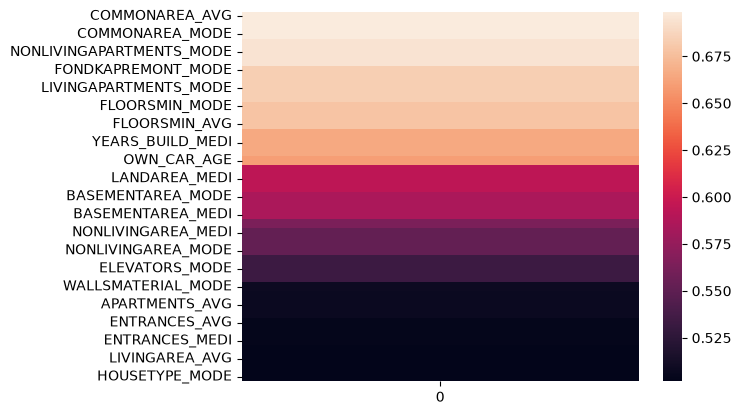

In [128]:
sns.heatmap(missing_value[missing_value>.5].sort_values(ascending=False).to_frame())

In [134]:
df.corr(numeric_only=True)["TARGET"].sort_values(ascending=False)

TARGET                         1.000000
DAYS_BIRTH                     0.078239
REGION_RATING_CLIENT_W_CITY    0.060893
REGION_RATING_CLIENT           0.058899
DAYS_LAST_PHONE_CHANGE         0.055218
                                 ...   
FLOORSMAX_AVG                 -0.044003
DAYS_EMPLOYED                 -0.044932
EXT_SOURCE_1                  -0.155317
EXT_SOURCE_2                  -0.160472
EXT_SOURCE_3                  -0.178919
Name: TARGET, Length: 106, dtype: float64